# Customer Churn Prediction

## Business Problem
A telecommunications company wants to identify customers who are likely to leave so its retention team can contact them before they do.

## Dataset
The supplied Telco Customer Churn dataset includes customer details, subscribed services, billing information, and churn status. Each row represents one customer.

## Prediction Target
The target column is `Churn`:

- Yes: the customer left.
- No: the customer did not leave.

This is a supervised binary classification problem: the historical records contain known outcomes, and the model learns to predict one of these two classes.

## Objective
Build and evaluate a Decision Tree classifier, explain how it makes predictions, and provide a REST API that returns a churn prediction and probability.

## 1. Data Understanding
Load the dataset and inspect its size, structure, and customer records.

In [4]:
import pandas as pd

df = pd.read_csv("../TelcoCustomerChurn.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Types and Column Roles
Inspect how pandas stores each column and compare this with its meaning
in the data dictionary.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [7]:
categorical_columns = df.columns.drop([
    "customerID",
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
])

for column in categorical_columns:
    print(f"{column}: {df[column].unique()}")

gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract: <StringArray>
['Month-to-month', 'One year', '

### Missing Values and Blank Strings
Check both recognized missing values and fields containing only whitespace.

In [8]:
missing_counts = df.isna().sum()

blank_counts = df.apply(
    lambda column: column.astype("string").str.strip().eq("").sum()
)

pd.DataFrame({
    "Missing values": missing_counts,
    "Blank strings": blank_counts
})

,Missing values,Blank strings
customerID,0,0
gender,0,0
SeniorCitizen,0,0
Partner,0,0
Dependents,0,0
tenure,0,0
PhoneService,0,0
MultipleLines,0,0
InternetService,0,0
OnlineSecurity,0,0


In [9]:
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing after conversion:", total_charges_numeric.isna().sum())

df.loc[
    total_charges_numeric.isna(),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
]

Missing after conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


### Missing TotalCharges
`TotalCharges` was loaded as text. Converting it to numbers revealed 11 blank entries, all belonging to customers with zero tenure.

I kept these customers in the dataset and left the charges missing for now. The preprocessing pipeline will fill them using the training-data median.

In [10]:
print("Duplicate complete rows:", df.duplicated().sum())
print("Repeated customer IDs:", df["customerID"].duplicated().sum())

Duplicate complete rows: 0
Repeated customer IDs: 0


In [11]:
churn_counts = df["Churn"].value_counts(dropna=False)
churn_percentages = df["Churn"].value_counts(
    normalize=True, dropna=False
) * 100

pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percentages.round(2)
})

,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


### What the Initial Checks Show

- The dataset has 7,043 rows and 21 columns.
- There are no duplicate rows or repeated customer IDs.
- `TotalCharges` has 11 blank entries, all for customers with zero tenure.
- 5,174 customers (73.46%) did not churn, while 1,869 (26.54%) did.

Since most customers did not churn, a high accuracy score alone would not tell us whether the model is good at finding those who leave.

## 2. Data Preparation

In [16]:
clean_df = df.copy()

clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

X = clean_df.drop(columns=["customerID", "Churn"])
y = clean_df["Churn"].map({"No": 0, "Yes": 1})

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

pd.DataFrame({
    "Training percentage": y_train.value_counts(normalize=True) * 100,
    "Testing percentage": y_test.value_counts(normalize=True) * 100
}).round(2)

Training shape: (4930, 19)
Testing shape: (2113, 19)


,Training percentage,Testing percentage
Churn,,
0,73.47,73.45
1,26.53,26.55


### Keeping the Test Data Separate
I used a 70/30 training and test split with `random_state=42` so the split can be reproduced. Stratification keeps the churn proportions approximately the same in both sets.

The exploration and model comparison below use only the training data. Imputation values and category mappings are also learned from training data, leaving the test set for the final evaluation.

## 3. Exploratory Data Analysis
I used the training data to look for differences between customers who churned and those who stayed. These comparisons help identify potential predictors, but they cannot tell us whether changing a customer's contract, service, or payment method would prevent churn.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

eda_df = X_train.copy()
eda_df["Churn"] = y_train
eda_df["ChurnLabel"] = y_train.map({0: "No", 1: "Yes"})

Matplotlib is building the font cache; this may take a moment.


### Churn Distribution

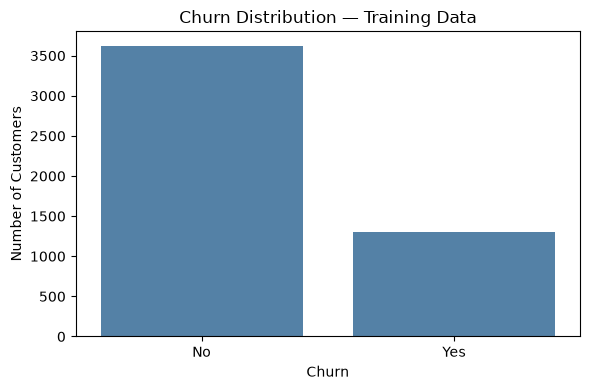

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=eda_df,
    x="ChurnLabel",
    order=["No", "Yes"],
    color="steelblue"
)

plt.title("Churn Distribution — Training Data")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Churn Distribution: What Stands Out
In the training set, 26.53% of customers churned and 73.47% stayed. Churners are the smaller group, so I will look at recall and precision alongside accuracy when comparing the models.

In [19]:
contract_summary = eda_df.groupby("Contract")["Churn"].agg(
    CustomerCount="count",
    ChurnRate="mean"
)

contract_summary["ChurnRate"] *= 100

display(contract_summary.round(2))

,CustomerCount,ChurnRate
Contract,,
Month-to-month,2704,42.86
One year,1034,10.93
Two year,1192,3.02


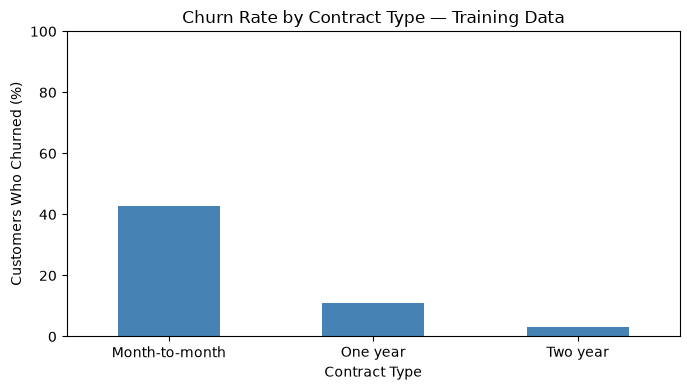

In [20]:
contract_summary["ChurnRate"].plot(
    kind="bar",
    figsize=(7, 4),
    color="steelblue",
    rot=0
)

plt.title("Churn Rate by Contract Type — Training Data")
plt.xlabel("Contract Type")
plt.ylabel("Customers Who Churned (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Contract Type
Month-to-month customers have a churn rate of 42.86%, compared with 10.93% for one-year contracts and 3.02% for two-year contracts. They also make up the largest contract group, with 2,704 customers.

I would start the retention analysis with this group because it combines a high churn rate with a large number of customers.

,CustomerCount,ChurnRate
InternetService,,
DSL,1685,19.17
Fiber optic,2177,41.85
No,1068,6.93


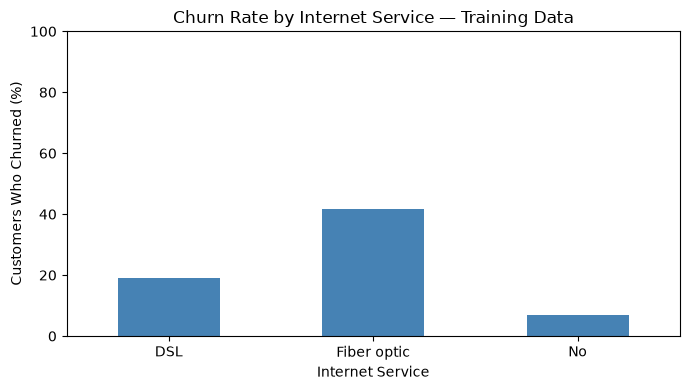

In [22]:
internet_summary = eda_df.groupby("InternetService")["Churn"].agg(
    CustomerCount="count",
    ChurnRate="mean"
)

internet_summary["ChurnRate"] *= 100
display(internet_summary.round(2))

internet_summary["ChurnRate"].plot(
    kind="bar",
    figsize=(7, 4),
    color="steelblue",
    rot=0
)

plt.title("Churn Rate by Internet Service — Training Data")
plt.xlabel("Internet Service")
plt.ylabel("Customers Who Churned (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

,CustomerCount,ChurnRate
PaymentMethod,,
Bank transfer (automatic),1086,16.30
Credit card (automatic),1067,14.71
Electronic check,1654,45.65
Mailed check,1123,19.50


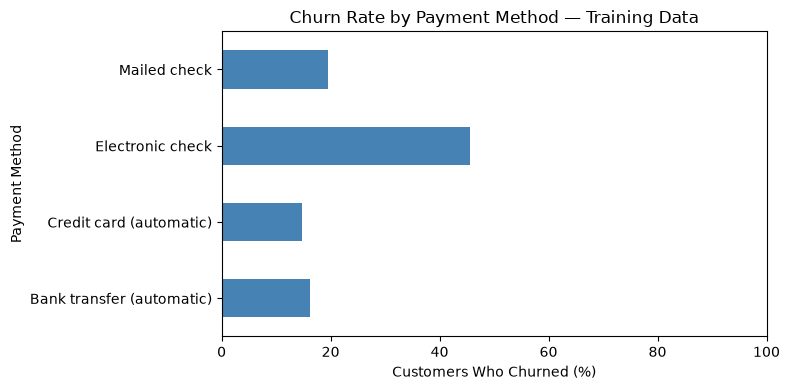

In [23]:
payment_summary = eda_df.groupby("PaymentMethod")["Churn"].agg(
    CustomerCount="count",
    ChurnRate="mean"
)

payment_summary["ChurnRate"] *= 100
display(payment_summary.round(2))

payment_summary["ChurnRate"].plot(
    kind="barh",
    figsize=(8, 4),
    color="steelblue"
)

plt.title("Churn Rate by Payment Method — Training Data")
plt.xlabel("Customers Who Churned (%)")
plt.ylabel("Payment Method")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Internet Service
Churn is highest among fiber-optic customers at 41.85%, compared with 19.17% for DSL and 6.93% for customers without internet service. Fiber optic is also the largest service group, with 2,177 customers.

I would investigate why churn is higher in this group. Pricing, service experience, and contract type are possible explanations to explore; this chart alone cannot distinguish between them.

,CustomerCount,ChurnRate
PaymentMethod,,
Bank transfer (automatic),1086,16.30
Credit card (automatic),1067,14.71
Electronic check,1654,45.65
Mailed check,1123,19.50


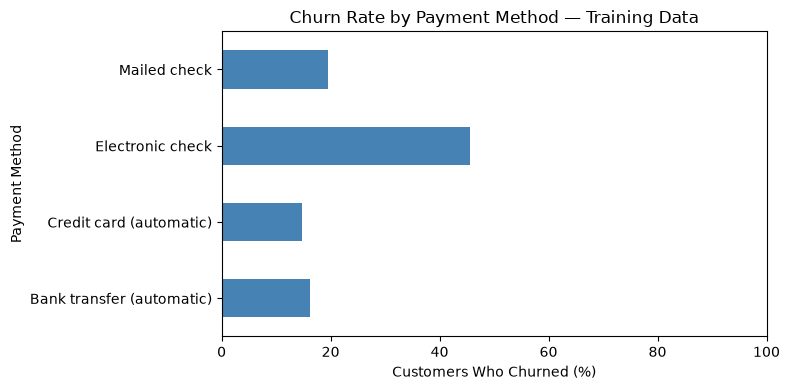

In [23]:
payment_summary = eda_df.groupby("PaymentMethod")["Churn"].agg(
    CustomerCount="count",
    ChurnRate="mean"
)

payment_summary["ChurnRate"] *= 100
display(payment_summary.round(2))

payment_summary["ChurnRate"].plot(
    kind="barh",
    figsize=(8, 4),
    color="steelblue"
)

plt.title("Churn Rate by Payment Method — Training Data")
plt.xlabel("Customers Who Churned (%)")
plt.ylabel("Payment Method")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Payment Method
Electronic-check customers have the highest churn rate at 45.65%. The rates are lower for mailed checks (19.50%), automatic bank transfers (16.30%), and automatic credit card payments (14.71%).

Both automatic-payment groups have lower churn than the other groups. This is the pattern behind the automatic-payment indicator introduced in the next section.

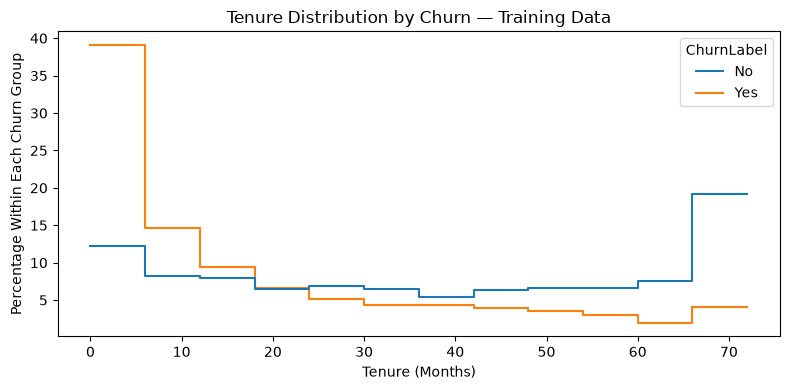

In [24]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=eda_df,
    x="tenure",
    hue="ChurnLabel",
    hue_order=["No", "Yes"],
    binwidth=6,
    stat="percent",
    common_norm=False,
    element="step",
    fill=False
)

plt.title("Tenure Distribution by Churn — Training Data")
plt.xlabel("Tenure (Months)")
plt.ylabel("Percentage Within Each Churn Group")
plt.tight_layout()
plt.show()

### Tenure
Customers who churned tend to have shorter tenures: their median is 10 months, compared with 38 months for customers who stayed. This makes the early customer experience a useful area to investigate for retention.

The chart compares tenure distributions within each churn group. It does not show the probability of churn at a given tenure.

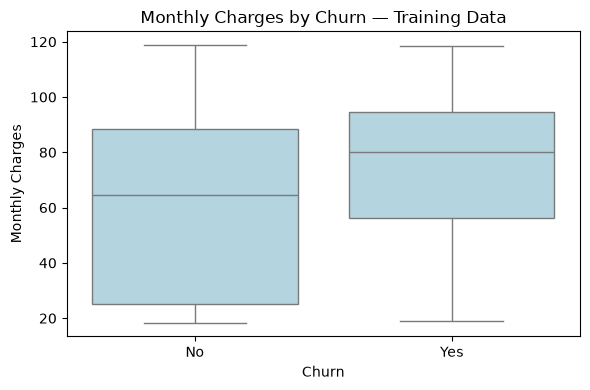

In [25]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=eda_df,
    x="ChurnLabel",
    y="MonthlyCharges",
    order=["No", "Yes"],
    color="lightblue"
)

plt.title("Monthly Charges by Churn — Training Data")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

### Monthly Charges
The median monthly charge is 80.00 for churners and 64.45 for non-churners. There is still considerable overlap between the two groups, so monthly charges alone do not clearly separate customers who leave from those who stay.

In [26]:
numerical_summary = eda_df.groupby("ChurnLabel").agg(
    CustomerCount=("Churn", "size"),
    MedianTenure=("tenure", "median"),
    MedianMonthlyCharges=("MonthlyCharges", "median")
)

display(numerical_summary.round(2))

,CustomerCount,MedianTenure,MedianMonthlyCharges
ChurnLabel,,,
No,3622,38.0,64.45
Yes,1308,10.0,80.00


## 4. Feature Engineering
I added two features to summarize service use and payment behaviour, while keeping the original columns.

### AdditionalServiceCount
This counts the services marked `Yes` across `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies`. The count ranges from 0 to 6; `No` and `No internet service` contribute zero.

For example, a customer with only OnlineSecurity and TechSupport receives a count of 2. The tree can then split on the number of additional services in one step.

A count of zero could mean no internet connection or an internet connection without additional services. Keeping `InternetService` lets the model distinguish between those cases.

### UsesAutomaticPayment
This is 1 for `Bank transfer (automatic)` or `Credit card (automatic)`, and 0 for `Electronic check` or `Mailed check`.

The automatic-payment groups had lower churn in the training data. Combining them gives the tree a way to split on automatic-payment status directly.

Both features use existing customer attributes, without using `Churn`. The same calculations are applied to training and test data and must also be used by the API. These are useful summaries to try, but this analysis does not establish whether they improve performance over the original features alone.

In [27]:
def add_features(data):
    result = data.copy()

    service_columns = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

    result["AdditionalServiceCount"] = (
        result[service_columns].eq("Yes").sum(axis=1)
    )

    automatic_methods = [
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]

    result["UsesAutomaticPayment"] = (
        result["PaymentMethod"].isin(automatic_methods).astype(int)
    )

    return result


X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

In [28]:
print("Training shape:", X_train_fe.shape)
print("Testing shape:", X_test_fe.shape)

X_train_fe[
    ["PaymentMethod", "AdditionalServiceCount", "UsesAutomaticPayment"]
].head()

Training shape: (4930, 21)
Testing shape: (2113, 21)


,PaymentMethod,AdditionalServiceCount,UsesAutomaticPayment
5557,Electronic check,1,0
2270,Electronic check,2,0
6930,Credit card (automatic),0,1
2257,Credit card (automatic),4,1
898,Bank transfer (automatic),4,1


## 5. Preprocessing Pipeline
I used median imputation for numerical columns to keep customers with missing `TotalCharges` in the analysis. The median is a simple estimate of the missing amount; it does not recover the customer's actual charges.

Categorical columns are one-hot encoded, giving each category its own binary column. Existing binary indicators remain numerical. Feature scaling is not needed for a Decision Tree.

Preprocessing and the tree are combined in a pipeline. This ensures that imputation values and category mappings are learned only from the training data, including separately within each cross-validation fold.

In [29]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AdditionalServiceCount",
    "UsesAutomaticPayment"
]

categorical_features = X_train_fe.columns.drop(
    numeric_features
).tolist()

print("Numerical/binary columns:", len(numeric_features))
print("Categorical columns:", len(categorical_features))
print(categorical_features)

Numerical/binary columns: 6
Categorical columns: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [31]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

## 6. Model Development
I compared two Decision Tree configurations:

- Default tree: no explicit depth limit.
- Restricted tree: a maximum depth of 5 and at least 20 training observations per leaf.

The restricted tree is a starting point for reducing overfitting. These settings have not been established as optimal.

Both models use the same three-fold stratified cross-validation splits within the training set, with preprocessing fitted separately in each fold. My initial priority is churn recall, since missed churners mean missed chances for outreach. Precision and F1 help assess the cost of flagging customers who would have stayed.

In [32]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Default Tree": clone(pipeline),
    "Restricted Tree": clone(pipeline).set_params(
        model__max_depth=5,
        model__min_samples_leaf=20
    )
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

In [33]:
comparison_rows = []

for name, candidate in models.items():
    scores = cross_validate(
        candidate,
        X_train_fe,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        return_estimator=True
    )

    depths = [
        fitted_pipeline.named_steps["model"].get_depth()
        for fitted_pipeline in scores["estimator"]
    ]

    comparison_rows.append({
        "Model": name,
        "Train Recall": scores["train_recall"].mean(),
        "Validation Accuracy": scores["test_accuracy"].mean(),
        "Validation Precision": scores["test_precision"].mean(),
        "Validation Recall": scores["test_recall"].mean(),
        "Validation F1": scores["test_f1"].mean(),
        "Mean Tree Depth": sum(depths) / len(depths)
    })

comparison = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison.round(4))

,Train Recall,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Mean Tree Depth
Model,,,,,,
Default Tree,0.9935,0.7367,0.5033,0.5482,0.5247,23.6667
Restricted Tree,0.5703,0.7927,0.6259,0.5451,0.5825,5.0000


### Model Comparison and Selection
The cross-validation results show a clear difference in precision, despite similar recall:

| Measure | Default tree | Restricted tree |
|---|---|---|
| Validation accuracy | 73.67% | 79.27% |
| Validation precision | 50.33% | 62.59% |
| Validation recall | 54.82% | 54.51% |
| Validation F1 | 0.5247 | 0.5825 |
| Mean tree depth | 23.67 | 5 |

The default tree's training recall is 99.35%, but its validation recall drops to 54.82%. That large gap suggests overfitting. The restricted tree has a much smaller gap: 57.03% on training data and 54.51% on validation data.

### Why I Selected the Restricted Tree
My initial plan was to choose the model with the highest recall. After reviewing cross-validation, I chose the restricted tree: its recall is only 0.31 percentage points lower, while its precision is 12.26 percentage points higher. Its F1 and accuracy are also better.

Both models find about 55 of every 100 actual churners in validation. With the restricted tree, about 63% of churn flags are correct, compared with 50% for the default tree. That means fewer unnecessary contacts among flagged customers.

I accepted the small observed drop in recall for better precision and a smaller tree that is easier to explain. The close recall scores do not, by themselves, establish statistical equivalence.

### Balancing Recall and Precision
Recall is my main business priority: a false negative means a customer who churns is missed by the model and may not receive outreach.

Precision matters too. A false positive flags a customer who would have stayed, using staff time and possibly leading to an unnecessary offer. The right balance would depend on contact costs and the team's capacity, neither of which is provided in this assignment.

The selected model's validation recall is 54.51%, so it still misses roughly 45% of actual churners. This is a limitation to keep in mind when considering how the team might use it.

In [35]:
final_pipeline = clone(models["Restricted Tree"])
final_pipeline.fit(X_train_fe, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges', 'AdditionalServiceCount','UsesAutomaticPayment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

## 7. Model Evaluation

Accuracy     0.7941
Precision    0.6145
Recall       0.6025
F1           0.6085
Name: Score, dtype: float64

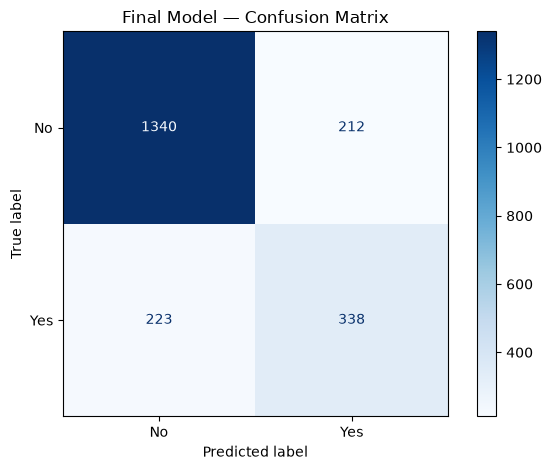

Correctly identified non-churners: 1340
Non-churners incorrectly flagged: 212
Missed churners: 223
Correctly identified churners: 338


In [36]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

y_pred = final_pipeline.predict(X_test_fe)

evaluation = pd.Series({
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0)
}, name="Score")

display(evaluation.round(4))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
).plot(cmap="Blues", values_format="d")

plt.title("Final Model — Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("Correctly identified non-churners:", tn)
print("Non-churners incorrectly flagged:", fp)
print("Missed churners:", fn)
print("Correctly identified churners:", tp)

### Final Evaluation: What the Results Mean
The selected tree was evaluated on the 2,113 customers held aside for testing.

| Metric | Result |
|---|---|
| Accuracy | 79.41% |
| Precision | 61.45% |
| Recall | 60.25% |
| F1 score | 0.6085 |

It correctly classified 1,678 customers. The confusion matrix shows where it succeeded and where it made mistakes:

- True positives: 338 churners correctly flagged for potential outreach.
- False negatives: 223 churners missed by the model.
- False positives: 212 non-churners incorrectly flagged.
- True negatives: 1,340 non-churners correctly identified.

If the retention team contacted everyone flagged, it would reach 550 people: 338 actual churners and 212 non-churners. That gives the team a concrete sense of the workload and how many contacts would be unnecessary according to these historical labels.

The main weakness is missed churners. Recall is 60.25%, which means 39.75% of actual churners were missed. Precision is 61.45%, so roughly six in ten flagged customers actually churned.

These results measure how well the model predicts historical churn. They do not tell us how many customers would stay after receiving a retention offer.

## 8. Understanding the Model
The feature importance scores and decision paths below help explain what the fitted tree uses to make predictions.

In [37]:
fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
fitted_tree = final_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": fitted_tree.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(10))

,Feature,Importance
38,categorical__Contract_Month-to-month,0.516216
1,numeric__tenure,0.178295
18,categorical__InternetService_Fiber optic,0.154271
45,categorical__PaymentMethod_Electronic check,0.032272
2,numeric__MonthlyCharges,0.024261
29,categorical__TechSupport_No,0.023913
3,numeric__TotalCharges,0.022823
16,categorical__MultipleLines_Yes,0.016235
20,categorical__OnlineSecurity_No,0.010224
35,categorical__StreamingMovies_No,0.007827


### Top Ten Features

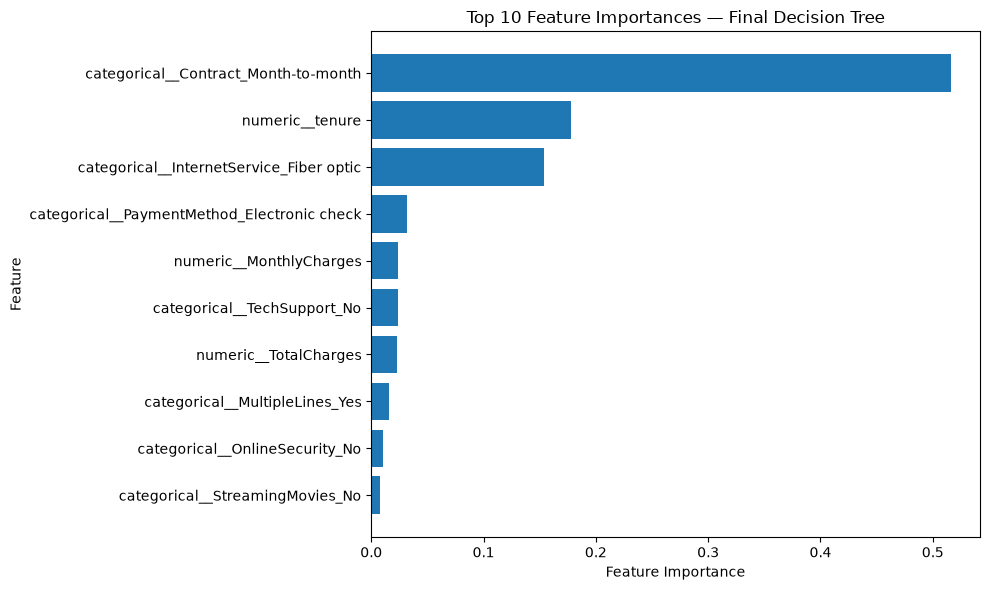

In [38]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Feature Importances — Final Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### What the Tree Relies On
The three most important encoded features are:

- Month-to-month contract: 0.5162.
- Tenure: 0.1783.
- Fiber-optic internet service: 0.1543.

Together, they account for about 84.88% of the tree's total impurity-based importance. Contract type, tenure, and internet service therefore account for most of this importance measure, which fits the patterns seen during exploration.

Electronic-check payment, monthly charges, and technical-support status make smaller contributions.

These scores describe how the fitted tree uses the features. They do not show whether a feature increases or decreases predicted churn, or whether changing it would prevent churn. Correlated features can also share or substitute for each other's importance, and features outside the top ten may still contribute. The ranking alone does not establish a benefit from the engineered features.

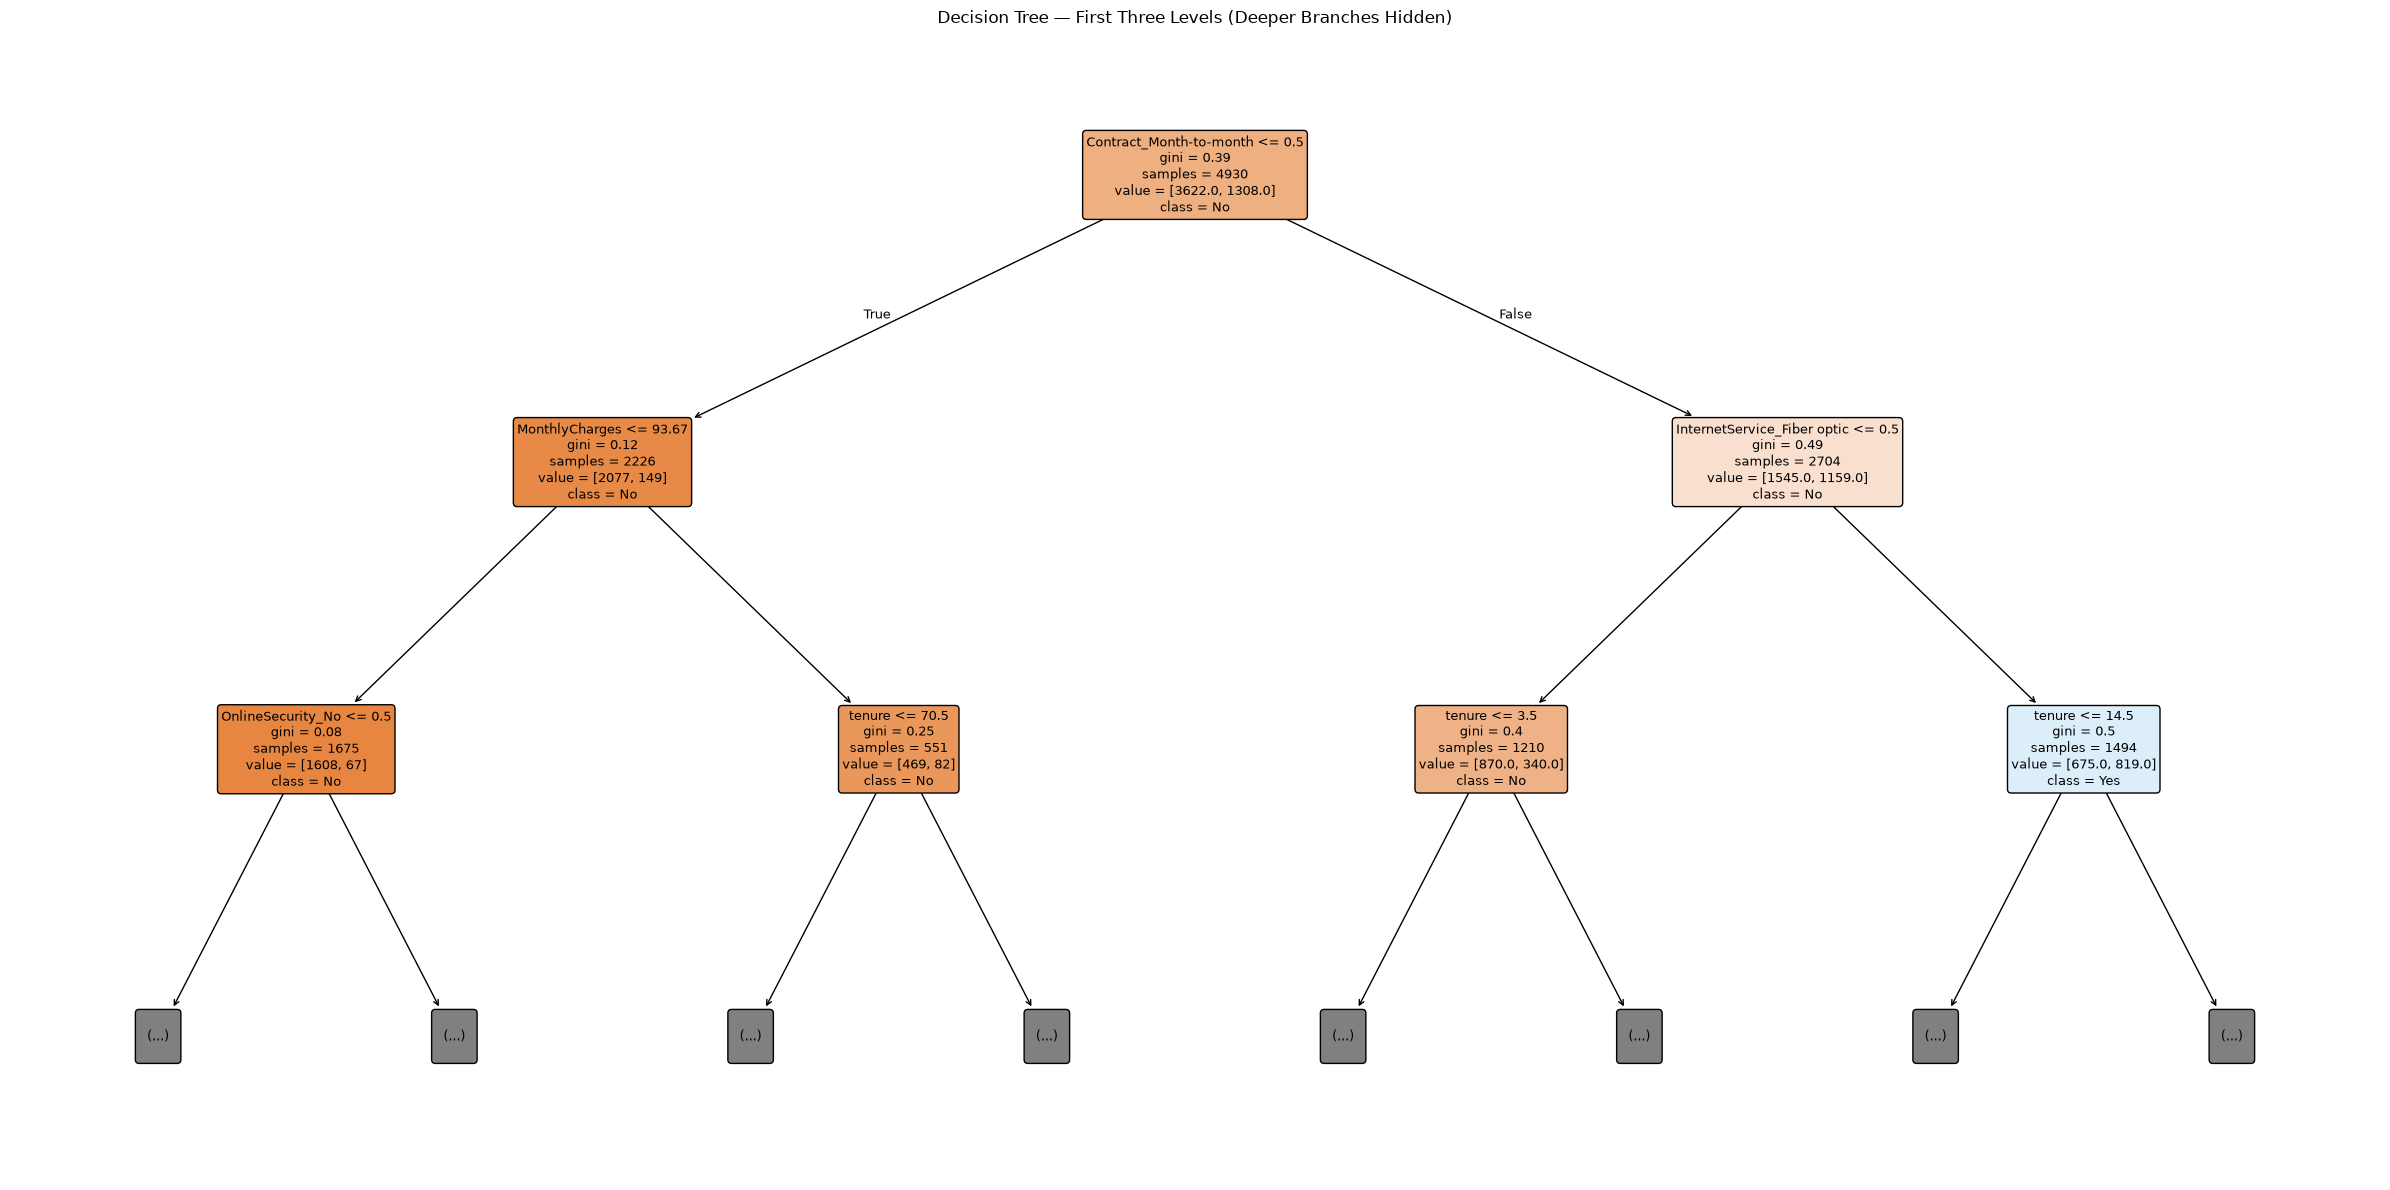

Full tree depth: 5
Number of leaves: 32


In [39]:
from sklearn.tree import plot_tree, export_text

display_feature_names = [
    name.split("__", 1)[-1]
    for name in feature_names
]

plt.figure(figsize=(24, 12))

plot_tree(
    fitted_tree,
    feature_names=display_feature_names,
    class_names=["No", "Yes"],
    max_depth=2,
    filled=True,
    rounded=True,
    precision=2,
    fontsize=9
)

plt.title("Decision Tree — First Three Levels (Deeper Branches Hidden)")
plt.tight_layout()
plt.show()

print("Full tree depth:", fitted_tree.get_depth())
print("Number of leaves:", fitted_tree.get_n_leaves())

In [40]:
tree_rules = export_text(
    fitted_tree,
    feature_names=display_feature_names,
    max_depth=fitted_tree.get_depth(),
    decimals=3
)

print(tree_rules)

|--- Contract_Month-to-month <= 0.500
|   |--- MonthlyCharges <= 93.675
|   |   |--- OnlineSecurity_No <= 0.500
|   |   |   |--- PaymentMethod_Electronic check <= 0.500
|   |   |   |   |--- MonthlyCharges <= 70.050
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- MonthlyCharges >  70.050
|   |   |   |   |   |--- class: 0
|   |   |   |--- PaymentMethod_Electronic check >  0.500
|   |   |   |   |--- OnlineBackup_No <= 0.500
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- OnlineBackup_No >  0.500
|   |   |   |   |   |--- class: 0
|   |   |--- OnlineSecurity_No >  0.500
|   |   |   |--- tenure <= 49.500
|   |   |   |   |--- PaperlessBilling_No <= 0.500
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- PaperlessBilling_No >  0.500
|   |   |   |   |   |--- class: 0
|   |   |   |--- tenure >  49.500
|   |   |   |   |--- PaymentMethod_Electronic check <= 0.500
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- PaymentMethod_Electronic check >  0.500
|   |   |   |   |   |-

### Following Two Decision Paths
The tree first checks whether the customer has a month-to-month contract. Each later split narrows the group until a leaf gives the prediction.

The following two complete paths share their first four conditions:

1. The contract is month-to-month.
2. Internet service is fiber optic.
3. Tenure is greater than 14.5 months.
4. Payment method is electronic check.

The final condition separates the predictions:

- **Churn = Yes:** tenure is at most 54.5 months. With tenure recorded in whole months, this path covers 15 to 54 months.
- **Churn = No:** tenure is greater than 54.5 months, meaning at least 55 months.

Within this combination of contract, service, and payment method, tenure determines which of these two leaves the customer reaches. This is a useful example of why the tree's prediction depends on several attributes together.

These paths describe patterns learned from historical training data, so they are not guarantees for individual customers. The diagram shows only the first three node levels for readability; the exported text includes the complete tree.

## 9. Saving the Model
I save the fitted preprocessing and Decision Tree together as `model/churn_model.pkl` using joblib. This is the same model evaluated on the test set.

The saved pipeline includes the learned imputation values, category encodings, and fitted tree. Numeric conversion and the two feature-engineering calculations remain outside the pipeline, so the API must apply them before passing customer data to the model.

In [42]:
from pathlib import Path
import joblib

model_path = Path("../model/churn_model.pkl")
model_path.parent.mkdir(exist_ok=True)

joblib.dump(final_pipeline, model_path)

print("Saved pipeline to:", model_path.resolve())

Saved pipeline to: C:\WorkData\NAGP26\NAG26_Sahil_3175225_DS\model\churn_model.pkl
